# Flow Matching for Simulation-Based Inference. Part 1: From Scratch

**LISA AI Hackathon @ ESTEC. Tutorial by Maximilian Dax (Thursday, July 30, 2026)**

In Stephen's tutorial you saw how *neural posterior estimation* (NPE) uses discrete normalizing flows to
approximate posteriors $p(\theta \mid d)$ for gravitational-wave parameter estimation. In this tutorial we
replace the discrete flow with a **continuous normalizing flow (CNF)** trained via **flow matching** 
(see [Lipman+2022](https://arxiv.org/pdf/2210.02747), [Liu+2022](https://arxiv.org/abs/2209.03003), 
[Albergo+2022](https://arxiv.org/abs/2209.15571) for the original method and 
[Wildberger+2023](https://arxiv.org/abs/2305.17161) for its adaptation to SBI).


**Why flow matching?** Discrete flows allow for stable training with NLL losses, but they require highly 
constrained architectures to enable tractable densities and sampling (e.g., coupling or autoregressive
layers). This often works well in low dimensions, but the architectural constraints typically impede
scaling to high dimensions.
Flow matching on the other hand lets us parameterize the posterior with an *unconstrained* network:
we can use any architecture that maps $(t, \theta, d) \mapsto$ vector.

### Learning goals

1. Understand CNFs: a **vector field** transports a simple base distribution to the target along an ODE.
2. Implement the **conditional flow matching loss** from scratch (~5 lines!) and visualize the learned
   vector field and flow trajectories in 1D.
3. Compare **probability paths** (optimal transport vs. diffusion-like).
4. Extend the loss to the SBI conditional setting and infer parameters of a toy gravitational-wave
   signal, validated against MCMC.

*Part 1 is pure PyTorch, without specialized SBI libraries.*

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

try:
    import corner
except ImportError:
    %pip install -q corner
    import corner

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
torch.manual_seed(42)
np.random.seed(42);

device: cpu


# Section A: Flow matching in 1D

## A.1 The problem

We want to turn samples from a simple **base distribution** $p_0 = \mathcal{N}(0, 1)$ into samples from a
**target distribution** $p_1$ (below: a bimodal Gaussian mixture). A continuous normalizing flow does this
with a *time-dependent vector field* $v_t(\theta)$: starting from $\theta(0) \sim p_0$, we integrate the ODE

$$\frac{d\theta(t)}{dt} = v_t(\theta(t)), \qquad t \in [0, 1],$$

and the endpoint $\theta(1)$ should be distributed as $p_1$. The vector field is parameterized as a neural network.
We here start with a 1D example.

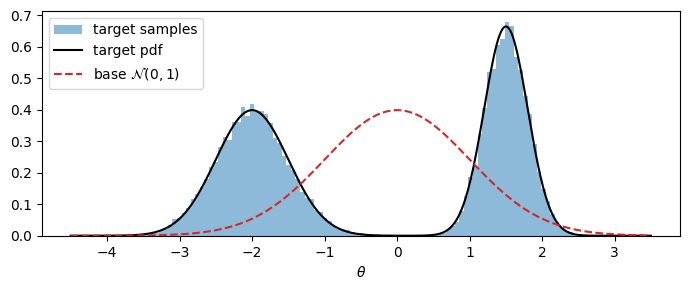

In [2]:
# Target: bimodal Gaussian mixture
def sample_target(n):
    comp = torch.rand(n, device=device) < 0.5
    return torch.where(
        comp,
        -2.0 + 0.5 * torch.randn(n, device=device),
        1.5 + 0.3 * torch.randn(n, device=device),
    )

def target_pdf(x):
    g = lambda x, m, s: np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    return 0.5 * g(x, -2.0, 0.5) + 0.5 * g(x, 1.5, 0.3)

xgrid = np.linspace(-4.5, 3.5, 400)
plt.figure(figsize=(7, 3))
plt.hist(sample_target(20000).cpu().numpy(), bins=100, density=True, alpha=0.5, label="target samples")
plt.plot(xgrid, target_pdf(xgrid), "k-", label="target pdf")
plt.plot(xgrid, np.exp(-xgrid**2 / 2) / np.sqrt(2 * np.pi), "C3--", label="base $\\mathcal{N}(0,1)$")
plt.legend(); plt.xlabel(r"$\theta$"); plt.tight_layout()

## A.2 CNF training with flow matching

We could train $v_t$ by maximum likelihood, just like we train discrete flows: 
the change-of-variables formula gives $\log p_1(\theta)$ in terms of an integral of the divergence 
of $v_t$ along the trajectory. But every training step would then require solving the full ODE, 
which typically corresponds to hundreds of network/vector field evaluations per step.

**Flow matching** sidesteps this. It derives an objective that allows us to directly regress the vector field $v_t$:

1. Pick a simple **conditional probability path**: for each target sample $\theta_1$, define how a base
   sample $\theta_0$ moves toward it as a function of $t$. We here use the *optimal transport* (OT) path,
   $$\theta_t = (1 - (1 - \sigma_{\min})\, t)\, \theta_0 + t\, \theta_1,$$
   a straight line from $\theta_0$ to $\theta_1$ (up to a residual noise scale $\sigma_{\min} \ll 1$).
2. The conditional vector field that generates this path is just its time derivative:
   $$u_t(\theta_t \mid \theta_0, \theta_1) = \theta_1 - (1 - \sigma_{\min})\, \theta_0.$$
3. **Regress** the network on it:
   $$\mathcal{L} = \mathbb{E}_{t,\, \theta_0 \sim p_0,\, \theta_1 \sim p_1}\,
   \big\| v_t(\theta_t) - u_t(\theta_t \mid \theta_0, \theta_1) \big\|^2.$$

Remarkably (and maybe somewhat surprisingly): By minimizing the this regression loss between the predicted 
vector field $v_t(\theta_t)$ and these *sample-conditional* vector fields $u_t(\theta_t \mid \theta_0, \theta_1)$,
one also minimizes the MSE less between $v_t(\theta_t)$ and the vector field $u_t(\theta_t))$ that generates the
(sample-)marginal path from $p_0$ to $p_1$. (see Appendix A in [Lipman+](https://arxiv.org/pdf/2210.02747))

We can thus train our vector field $v_t$ without ODE simulations, with just one network evaluation per sample.

### ✏️ Exercise for A.2

Implement `ot_path(theta_0, theta_1, t)` returning `(theta_t, u_t)` — the interpolated point and the
target vector field — and the flow-matching loss in the training loop below.

In [3]:
class VectorField(nn.Module):
    """Tiny MLP v(t, theta) -> R. Note: no architecture constraints whatsoever!"""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, t, x):
        return self.net(torch.stack([t, x], dim=-1)).squeeze(-1)


def ot_path(theta_0, theta_1, t, sigma_min=1e-4):
    """Optimal-transport conditional path: interpolant theta_t and target vector field u_t."""
    # SOLUTION
    theta_t = (1 - (1 - sigma_min) * t) * theta_0 + t * theta_1
    u_t = theta_1 - (1 - sigma_min) * theta_0
    # SOLUTION END
    return theta_t, u_t

In [4]:
def train_fm(path_fn, steps=3000, batch=1024, lr=1e-3):
    net = VectorField().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for i in range(steps):
        theta_1 = sample_target(batch)          # samples from the target
        theta_0 = torch.randn(batch, device=device)  # samples from the base
        t = torch.rand(batch, device=device)         # random times
        # SOLUTION
        theta_t, u_t = path_fn(theta_0, theta_1, t)
        loss = ((net(t, theta_t) - u_t) ** 2).mean()
        # SOLUTION END
        opt.zero_grad(); loss.backward(); opt.step()
        if i % 500 == 0:
            print(f"step {i:5d}   loss {loss.item():.3f}")
    return net

net_ot = train_fm(ot_path)

step     0   loss 4.599
step   500   loss 2.363
step  1000   loss 2.079
step  1500   loss 2.308
step  2000   loss 2.527
step  2500   loss 2.454


## A.3 Sampling with flow matching

To generate samples we draw $\theta(0) \sim \mathcal{N}(0,1)$ and integrate
$d\theta/dt = v_t(\theta)$ from $t=0$ to $1$. 

### ✏️ Exercise for A.3
Implement integration with a simple Euler scheme.

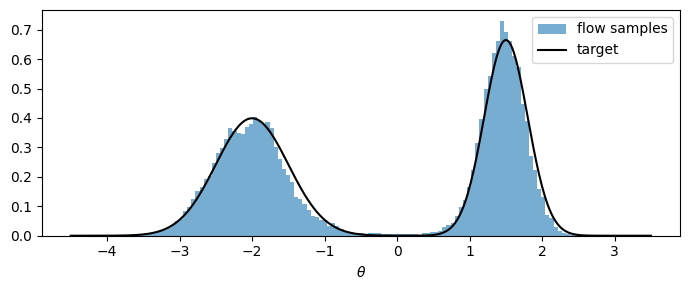

In [5]:
@torch.no_grad()
def integrate(net, theta0, n_steps=100, keep_traj=False):
    theta = theta0.clone()
    traj = [theta.clone()]
    dt = 1.0 / n_steps
    for i in range(n_steps):
        # SOLUTION
        t = torch.full_like(theta, i * dt)
        theta = theta + dt * net(t, theta)   # Euler step
        # SOLUTION END
        if keep_traj:
            traj.append(theta.clone())
    return (theta, torch.stack(traj)) if keep_traj else theta

samples = integrate(net_ot, torch.randn(50000, device=device))
plt.figure(figsize=(7, 3))
plt.hist(samples.cpu().numpy(), bins=120, density=True, alpha=0.6, label="flow samples")
plt.plot(xgrid, target_pdf(xgrid), "k-", lw=1.5, label="target")
plt.legend(); plt.xlabel(r"$\theta$"); plt.tight_layout()

## A.4 sample trajectories and vector field

In 1D, $v_t(\theta)$ is a function of two variables. Below, we plot it as a heatmap over the $(t, \theta)$ plane and
overlay flow trajectories. Watch how the base distribution's samples get routed into the two modes.

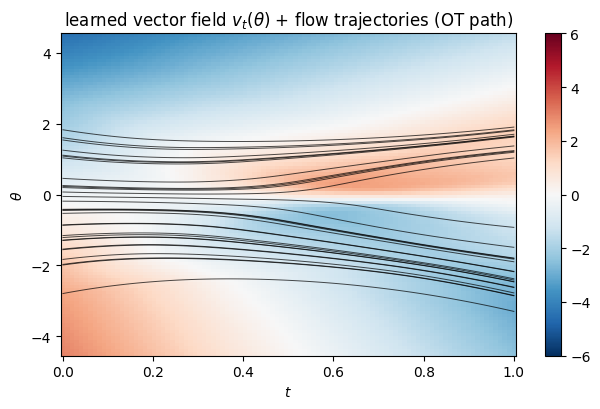

In [6]:
def plot_vf(net, ax, title, n_traj=30):
    tg = torch.linspace(0, 1, 100, device=device)
    xg = torch.linspace(-4.5, 4.5, 100, device=device)
    T, X = torch.meshgrid(tg, xg, indexing="ij")
    with torch.no_grad():
        V = net(T.flatten(), X.flatten()).reshape(T.shape)
    pc = ax.pcolormesh(T.cpu(), X.cpu(), V.cpu(), cmap="RdBu_r", vmin=-6, vmax=6)
    _, traj = integrate(net, torch.randn(n_traj, device=device), keep_traj=True)
    ax.plot(np.linspace(0, 1, traj.shape[0]), traj.cpu().numpy(), color="k", lw=0.7, alpha=0.7)
    ax.set(title=title, xlabel="$t$", ylabel=r"$\theta$")
    return pc

fig, ax = plt.subplots(figsize=(6.5, 4.2))
pc = plot_vf(net_ot, ax, "learned vector field $v_t(\\theta)$ + flow trajectories (OT path)")
plt.colorbar(pc, ax=ax); plt.tight_layout()

## A.5 Bonus: Sample paths

While above we chose to impose straight-line (OT) sample paths, we are free to use other interpolants.
Any $\theta_t = \alpha_t \theta_1 + \beta_t \theta_0$
with $(\alpha_0, \beta_0) = (0, 1)$ and $(\alpha_1, \beta_1) \approx (1, 0)$ defines a valid conditional path with
target field $u_t = \dot\alpha_t \theta_1 + \dot\beta_t \theta_0$. A second important choice is the
**trigonometric** interpolant

$$\theta_t = \sin\!\big(\tfrac{\pi t}{2}\big)\, \theta_1 + \cos\!\big(\tfrac{\pi t}{2}\big)\, \theta_0 .$$

**Why this is "the diffusion path".** Conditional on $\theta_1$, any such interpolant is Gaussian,
$p_t(\theta_t \mid \theta_1) = \mathcal{N}(\alpha_t\, \theta_1,\ \beta_t^2)$. The forward (noising) process of
denoising diffusion models (the variance-preserving (VP) SDE underlying DDPM) produces noisy samples of
exactly this form, with schedules satisfying

$$\alpha_t^2 + \beta_t^2 = 1 .$$

This constraint is what "variance-preserving" means: for unit-variance data the marginal variance is $1$ at
*every* $t$, ie noise is rotated in rather than added on top. Every VP schedule can be written
$\alpha_t = \sin u(t)$, $\beta_t = \cos u(t)$ for a monotone $u$; the trigonometric path is the simplest
choice $u(t) = \pi t / 2$ (the "cosine schedule" in the diffusion literature), time-reversed to the flow-matching
convention (noise at $t = 0$, data at $t = 1$).

Flow matching on this path learns the velocity of the ODE that shares its marginals with the diffusion, ie
the *probability-flow ODE*. Since velocity and score are related linearly at each $t$, regressing the
velocity on the VP path and denoising score matching learn the same object in different parameterizations.

The OT path instead satisfies $\alpha_t + \beta_t \approx 1$ (linear in the standard deviations rather than
the variances) so the marginal variance dips at intermediate $t$ instead of staying constant.

### ✏️ Exercise for A.5

Implement the trigonometric path, retrain, and compare the two vector fields. Then re-sample **using very
few Euler steps**.

step     0   loss 5.093
step   500   loss 3.919
step  1000   loss 3.741
step  1500   loss 3.988
step  2000   loss 3.684
step  2500   loss 3.923


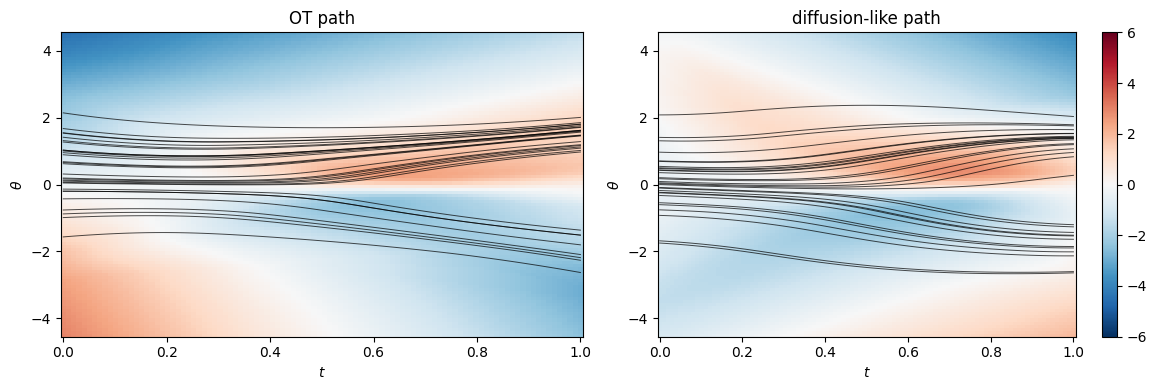

In [7]:
def trig_path(theta_0, theta_1, t):
    # SOLUTION
    c, s = torch.cos(np.pi * t / 2), torch.sin(np.pi * t / 2)
    theta_t = s * theta_1 + c * theta_0
    u_t = (np.pi / 2) * (c * theta_1 - s * theta_0)
    # SOLUTION END
    return theta_t, u_t

net_trig = train_fm(trig_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_vf(net_ot, axes[0], "OT path")
pc = plot_vf(net_trig, axes[1], "diffusion-like path")
plt.colorbar(pc, ax=axes[1]); plt.tight_layout()

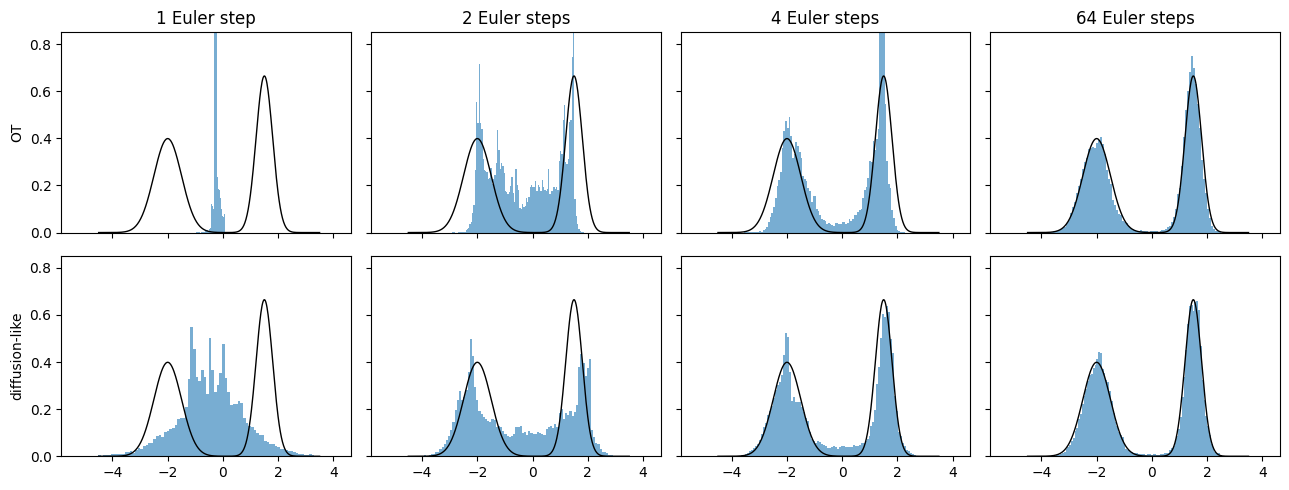

In [8]:
# Few-step sampling: how does each path degrade as we coarsen the ODE discretization?
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharex=True, sharey=True)
for row, (name, net) in enumerate([("OT", net_ot), ("diffusion-like", net_trig)]):
    for col, n_steps in enumerate([1, 2, 4, 64]):
        s = integrate(net, torch.randn(50000, device=device), n_steps=n_steps)
        ax = axes[row, col]
        ax.hist(s.cpu().numpy(), bins=100, density=True, alpha=0.6)
        ax.plot(xgrid, target_pdf(xgrid), "k-", lw=1)
        ax.set_ylim(0, 0.85)  # the 1-step histograms have off-scale spikes
        if row == 0: ax.set_title(f"{n_steps} Euler step{'s' if n_steps > 1 else ''}")
        if col == 0: ax.set_ylabel(name)
plt.tight_layout()

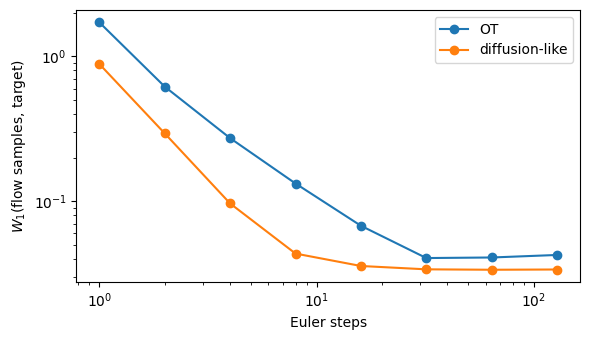

In [9]:
# Quantitative version: Wasserstein-1 distance to the target vs number of Euler steps
def w1(a, b):
    """1D W1 distance = mean absolute difference of sorted samples."""
    return (a.sort().values - b.sort().values).abs().mean().item()

torch.manual_seed(0)
ref = sample_target(100_000)
base = torch.randn(100_000, device=device)
step_list = [1, 2, 4, 8, 16, 32, 64, 128]

plt.figure(figsize=(6, 3.5))
for name, net in [("OT", net_ot), ("diffusion-like", net_trig)]:
    dists = [w1(integrate(net, base, n_steps=ns), ref) for ns in step_list]
    plt.loglog(step_list, dists, "o-", label=name)
plt.xlabel("Euler steps"); plt.ylabel(r"$W_1$(flow samples, target)")
plt.legend(); plt.tight_layout()

**Takeaways from Part A**

- A CNF is *just a vector field*; flow matching trains it by plain regression, no ODE solves at train time.
- The probability path is a design degree of freedom (OT ↔ diffusion/score matching), and it shapes few-step sampling error in non-obvious ways: straight *conditional* paths do not imply a straight *marginal* flow.
- The network is architecturally unconstrained.

## Section B: flow matching for simulation-based inference

## B.1 Conditional generative modeling for posterior estimation

So far, we have used flow matching to model an unconditional distribution over $\theta$.
Amortized posterior estimation in contrast requires a generative model conditional on observations $d$ to capture 
the posterior $p(\theta \mid d)$.

It is straightforward to extend flow matching to conditional distributions:

- make the vector field *conditional on data*: $v_t(\theta, d)$,
- draw training pairs from the joint: $\theta_1 \sim p(\theta)$ (the prior), $d \sim p(d \mid \theta_1)$ (the simulator),

$$\mathcal{L}_{\rm FMPE} = \mathbb{E}_{t,\, \theta_0,\, (\theta_1, d)}\,
\big\| v_t(\theta_t, d) - u_t(\theta_t \mid \theta_0, \theta_1) \big\|^2 .$$

Minimizing this loss results in a flow matching model $q(\theta \mid d)$ that approximates the posterior 
$p(\theta \mid d)$ for and $d \sim p(d)$. Just like NPE with discrete flows, flow matching thus enables
amortized inference.

## B.2 A toy GW like problem

We here build a simple simulator that produces a **damped sinusoid** in white noise:

$$s(t; \theta) = A \sin(2\pi f t)\, e^{-t/\tau}, \qquad \theta = (A, f, \tau), \qquad
d = s(t;\theta) + n, \quad n \sim \mathcal{N}(0, \sigma_n^2).$$

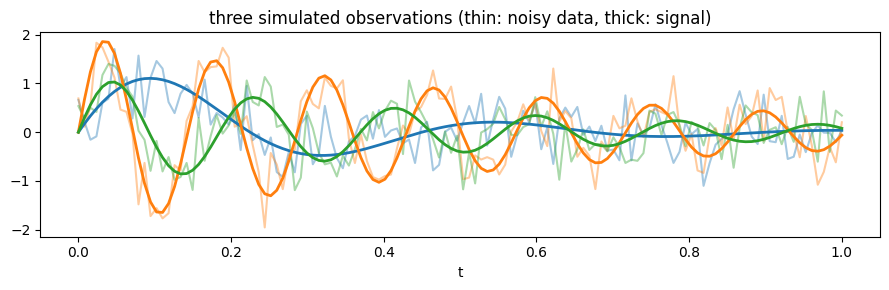

In [10]:
N_GRID, T_MAX, NOISE_STD = 128, 1.0, 0.4
t_grid = torch.linspace(0, T_MAX, N_GRID, device=device)

PRIOR_LOW = torch.tensor([0.5, 2.0, 0.1], device=device)   # A, f, tau
PRIOR_HIGH = torch.tensor([2.0, 8.0, 0.6], device=device)
LABELS = [r"$A$", r"$f$", r"$\tau$"]

def sample_prior(n):
    return PRIOR_LOW + (PRIOR_HIGH - PRIOR_LOW) * torch.rand(n, 3, device=device)

def signal(theta):
    A, f, tau = theta[:, 0:1], theta[:, 1:2], theta[:, 2:3]
    return A * torch.sin(2 * np.pi * f * t_grid) * torch.exp(-t_grid / tau)

def simulate(theta):
    return signal(theta) + NOISE_STD * torch.randn(theta.shape[0], N_GRID, device=device)

theta_demo = sample_prior(3)
plt.figure(figsize=(9, 3))
for i, d in enumerate(simulate(theta_demo).cpu()):
    plt.plot(t_grid.cpu(), d, alpha=0.4, color=f"C{i}")
for i, s in enumerate(signal(theta_demo).cpu()):
    plt.plot(t_grid.cpu(), s, color=f"C{i}", lw=2)
plt.xlabel("t"); plt.title("three simulated observations (thin: noisy data, thick: signal)")
plt.tight_layout()

## B.3 The conditional network

We add a small data-embedding MLP and concatenate its output with $(t, \theta)$. For real GW problems this
embedding becomes the workhorse (and can be *any* network, eg CNNs, transformers). Here an MLP is sufficient.

We standardize $\theta$ to zero mean and unit variance under the prior, such that the base distribution and the flow
live on a natural scale.

### ✏️ Exercise for B.3

Complete the FMPE training loop. It is *the same loss* as in the Exercise in A.2, the only changes are (1) sample
$(\theta_1, d)$ jointly from prior + simulator, and (2) pass $d$ to the network.

In [11]:
class FMPENet(nn.Module):
    def __init__(self, theta_dim=3, data_dim=N_GRID, hidden=256, embed_dim=64):
        super().__init__()
        self.data_embed = nn.Sequential(
            nn.Linear(data_dim, hidden), nn.GELU(), nn.Linear(hidden, embed_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(1 + theta_dim + embed_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, theta_dim),
        )
    def forward(self, t, theta, d):
        return self.net(torch.cat([t[:, None], theta, self.data_embed(d)], dim=-1))

THETA_MEAN = (PRIOR_LOW + PRIOR_HIGH) / 2
THETA_STD = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)

def train_fmpe(steps=5000, batch=1024, lr=3e-4, sigma_min=1e-3):
    net = FMPENet().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for i in range(steps):
        # SOLUTION
        theta = sample_prior(batch)
        d = simulate(theta)                      # joint samples (theta, d)
        theta_1 = (theta - THETA_MEAN) / THETA_STD  # standardized parameters
        theta_0 = torch.randn_like(theta_1)
        t = torch.rand(batch, device=device)
        theta_t = (1 - (1 - sigma_min) * t)[:, None] * theta_0 + t[:, None] * theta_1
        u_t = theta_1 - (1 - sigma_min) * theta_0
        loss = ((net(t, theta_t, d) - u_t) ** 2).mean()
        # SOLUTION END
        opt.zero_grad(); loss.backward(); opt.step()
        if i % 500 == 0:
            print(f"step {i:5d}   loss {loss.item():.3f}")
    return net

fmpe_net = train_fmpe()

step     0   loss 1.973
step   500   loss 0.673
step  1000   loss 0.572
step  1500   loss 0.559
step  2000   loss 0.528
step  2500   loss 0.523
step  3000   loss 0.490
step  3500   loss 0.475
step  4000   loss 0.499
step  4500   loss 0.478


### B.4 Inference on an observation

Generate one observation with known ground truth, sample the amortized posterior (Euler ODE), 
and compare against a Metropolis-Hastings reference that uses the
*exact* likelihood. This comparison is only possible because our toy has a tractable likelihood.
For real LISA sources, we may not always be able to implement a tractable likelihood and have to rely on SBI.

In [12]:
@torch.no_grad()
def sample_posterior(net, d_obs, n=10000, n_steps=64):
    theta = torch.randn(n, 3, device=device)
    d = d_obs.expand(n, -1)
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((n,), i * dt, device=device)
        theta = theta + dt * net(t, theta, d)
    return theta * THETA_STD + THETA_MEAN

theta_true = torch.tensor([[1.2, 5.0, 0.3]], device=device)
torch.manual_seed(7)
d_obs = simulate(theta_true)[0]

fmpe_samples = sample_posterior(fmpe_net, d_obs)

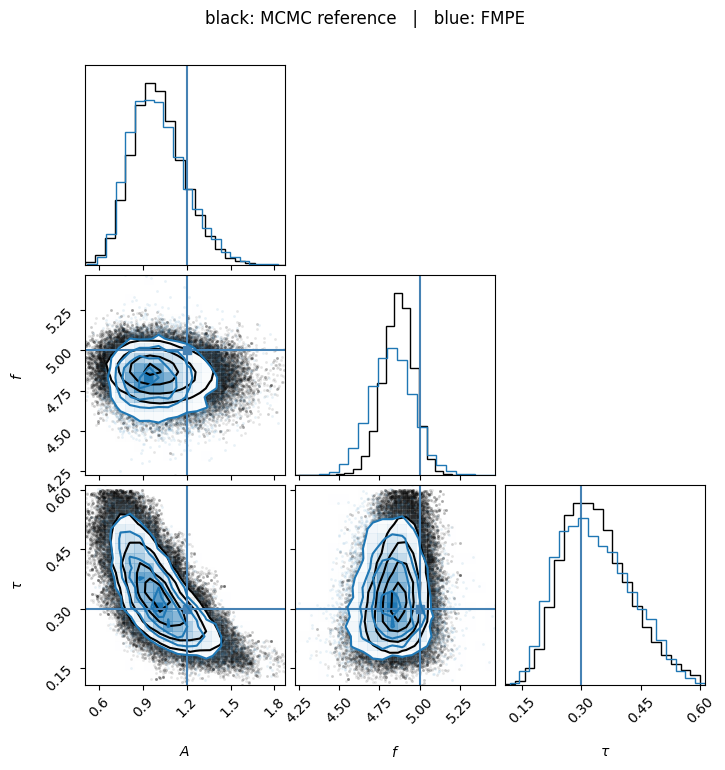

In [13]:
# Reference posterior: Metropolis-Hastings with the exact Gaussian likelihood (given utility)
def log_likelihood(theta, d_obs):
    return -0.5 * ((d_obs - signal(theta)) ** 2).sum(-1) / NOISE_STD ** 2

@torch.no_grad()
def mh_reference(d_obs, n_walkers=64, n_steps=4000, burn=1000):
    theta = sample_prior(n_walkers)
    logl = log_likelihood(theta, d_obs)
    step = 0.02 * (PRIOR_HIGH - PRIOR_LOW)
    chain = []
    for i in range(n_steps):
        prop = theta + step * torch.randn_like(theta)
        inb = ((prop >= PRIOR_LOW) & (prop <= PRIOR_HIGH)).all(-1)
        logl_prop = log_likelihood(prop, d_obs)
        acc = (torch.rand(n_walkers, device=device).log() < (logl_prop - logl)) & inb
        theta[acc] = prop[acc]; logl[acc] = logl_prop[acc]
        if i >= burn:
            chain.append(theta.clone())
    return torch.cat(chain)

mh_samples = mh_reference(d_obs)

fig = corner.corner(mh_samples.cpu().numpy(), labels=LABELS, color="k",
                    hist_kwargs={"density": True}, truths=theta_true[0].cpu().numpy())
corner.corner(fmpe_samples.cpu().numpy(), fig=fig, color="C0", hist_kwargs={"density": True})
fig.suptitle("black: MCMC reference   |   blue: FMPE", y=1.02);

### B.5 Discussion

If your training run matches ours, the FMPE posterior agrees well with MCMC, with perhaps a slight
mismatch in the $f$ marginal. Some things to try / think about:

- **Train longer / larger.** The residual mismatch is a *network accuracy* issue, not a method issue.
  Double `steps` or `hidden` and watch it shrink (fast on a GPU).
- **Amortization.** Re-run inference for a *different* observation (no retraining needed!). An MCMC run,
  in contrast, starts from scratch for every observation.
- **Validation.** Visual agreement with MCMC won't scale to real problems. In Part 2 we exploit that
  flow matching allows for *density evaluation* in addition to sampling. We can thus use importance
  sampling to validate and correct the inference result.

**You have now implemented, from scratch, conditional flow matching for SBI.** 
In Part 2 you'll see the identical loss inside DINGO's `FlowMatchingPosteriorModel` 
(it's ~5 of the same lines), and use the framework to tackle a LISA galactic binary.